# Inferring binding motifs from experimental data using deep learning

Here, we have a dataset of DNA sequences and whether a transcription factor (TF) binds them. We will build a few different models to predict TF binding from DNA sequence. In the process, we will implement a few different neural networks and examine what they learn.

This tutorial is adapted from the excellent paper: [A primer on deep learning in genomics](https://www.nature.com/articles/s41588-018-0295-5)

## Introduction and first look at input data
- 2000 DNA sequences (each has a length of 50 nucleotides) 
- Each sequence is labeled depending on its abilitiy to bind to a protein (transcription factor), we pretend this is the result of a binding assay
- If a seqeunce does NOT bind it gets the label 0 and if it binds it gets the label 1
- Each binding sequence has the regulatory motif *CGACCGAACTCC* somwhere in its sequence embedded.

### Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

import torch
import torch.nn as nn

In [2]:
sequences_url = 'https://raw.githubusercontent.com/abidlabs/deep-learning-genomics-primer/master/sequences.txt'

sequences = requests.get(sequences_url).text.split('\n')
sequences = list(filter(None, sequences))  # This removes empty sequences.

# Let's print the first few sequences.
pd.DataFrame(sequences, index=np.arange(1, len(sequences)+1),
             columns=['Sequences']).head()

,Sequences
1,CCGAGGGCTATGGTTTGGAAGTTAGAACCCTGGGGCTTCTCGCGGA...
2,GAGTTTATATGGCGCGAGCCTAGTGGTTTTTGTACTTGTTTGTCGC...
3,GATCAGTAGGGAAACAAACAGAGGGCCCAGCCACATCTAGCAGGTA...
4,GTCCACGACCGAACTCCCACCTTGACCGCAGAGGTACCACCAGAGC...
5,GGCGACCGAACTCCAACTAGAACCTGCATAACTGGCCTGGGAGATA...


### Read in data from file (alternative if the data can not be loaded from the repository)

In [3]:
# with open("sequences.txt") as f:
#     sequences = f.read()

# sequences = sequences.split('\n')

# sequences = list(filter(None, sequences))  # This removes empty sequences.

# # Let's print the first few sequences.
# pd.DataFrame(sequences, index=np.arange(1, len(sequences)+1),
#              columns=['Sequences']).head()

## Organize the data into a format that can be passed into a deep learning algorithm

- Most deep learning algorithms accept data in the form of vectors or matrices (or more generally, tensors).

- To get each DNA sequence in the form of a matrix, we use one-hot encoding

- One-hot endocing encodes every base in a sequence in the form of a 4-dimensional vector, with a separate dimension for each base. 

- We place a "1" in the dimension corresponding to the base found in the DNA sequence, and "0"s in all other slots. We then concatenate these 4-dimensional vectors together along the bases in the sequence to form a matrix.


### Show how a single sequence is one-hot encoded

In [4]:
def one_hot_encode(sequence):
    """Encode a DNA sequence as a (seq_len, 4) binary matrix. Columns: A, C, G, T"""
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((len(sequence), 4), dtype=np.float32)
    for i, base in enumerate(sequence):
        encoded[i, mapping[base]] = 1.0
    return encoded

# Take the first sequence to demonstrate
sequence = sequences[0]
print('First 10 bases:', sequence[:10])
print('One-hot encoded (first 10 rows, columns = A C G T):')
print(one_hot_encode(sequence[:10]))

First 10 bases: CCGAGGGCTA
One-hot encoded (first 10 rows, columns = A C G T):
[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


### One-hot encode all sequences

In [5]:
input_features = np.stack([one_hot_encode(seq) for seq in sequences])
print(input_features.shape)  # (2000, 50, 4):  2000 sequences, 50 bases each, 4 possible bases

(2000, 50, 4)


## Load and encode the labels 
- the labels are structured as follows: a "1" indicates that a protein bound to the sequence, while a "0" indicates that the protein did not. 
- We store labels as plain integers (0 or 1). PyTorch's `CrossEntropyLoss` expects integer class indices, not one-hot vectors.

In [6]:
labels_url = 'https://raw.githubusercontent.com/abidlabs/deep-learning-genomics-primer/master/labels.txt'

labels = requests.get(labels_url).text.split('\n')
labels = list(filter(None, labels))  # removes empty sequences

### Read in data from file (alternative if the data can not be loaded from the repository)

In [7]:
# with open("labels.txt") as f:
#     labels = f.read()
    
# labels = labels.split('\n')
# labels = list(filter(None, labels))  # removes empty sequences

In [8]:
input_labels = np.array(labels, dtype=np.int64)
print('First 10 labels:', input_labels[:10])
print(f'Class counts: {np.bincount(input_labels)}')  # how many 0s and 1s

First 10 labels: [0 0 0 1 1 1 1 0 0 0]
Class counts: [1013  987]


# Select the architecture and train the model

### Split the data into training and test sets. 
- The purpose of the test set is to ensure that we can observe the performance of the model on new data, not seen previously during training. 
- At a later step, we will further partition the training set into a training and validation set.

(1) Training dataset: a dataset used to fit the parameters of a model or to define the weights of connections between neurons of a neural network.

(2) Validation dataset: The weights of the network are not adjusted with this data set, however the set can be used to observe if the model is overfitting.

(3) Testing dataset: is a third dataset not included in the training nor validation data sets.
Used to measure the performance on new examples.

In [9]:
# Split data into train and test set (train set will later be split into train and validation)
from sklearn.model_selection import train_test_split

train_features, test_features, train_labels, test_labels = train_test_split(
    input_features, input_labels, test_size=0.25, random_state=42)

### Select the Architecture and Train

- Next, we define a neural network architecture. We use PyTorch, which represents models as Python classes.

- In PyTorch, every model inherits from `nn.Module`. You define:
  - `__init__`: the layers the model contains
  - `forward`: how data flows through those layers

- We build a simple 1D convolutional neural network (CNN), commonly used in functional genomics.

- **Important shape convention**: PyTorch's `Conv1d` expects input as `(batch, channels, length)`. Our sequences are encoded as `(batch, length, 4)`, so we will need to permute the axes before passing data to the model.
  - Model weights are updated in batches: small chunks of the training data. in this example, the dataset is small enough that the compute resources can handle the entire dataset, but for large scale models (like all public single-cell RNA-seq data), this is not feasible. In such cases, you'd train models with multiple GPUs and in small batches (often 32-128, but exact size depends on how much memory you have)

The architecture consists of:

- _Conv1d_: 32 filters with kernel size 12 — each filter learns to recognise a 12-base pattern.

- _MaxPool1d_: stride-4 pooling to downsample the 32 filter outputs.

- _Flatten_: collapses the pooled output into a single vector per sequence.

- _Linear (16 units, ReLU)_: compresses the representation.

- _Linear (2 units)_: the output layer, one score per class. `CrossEntropyLoss` applies softmax internally, so we do not add it here.

(show the cnn.png figure to explain the layers)

In [10]:
class MotifCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv  = nn.Conv1d(in_channels=4, out_channels=32, kernel_size=12)
        self.pool  = nn.MaxPool1d(kernel_size=4)
        self.flatten = nn.Flatten()
        self.fc1   = nn.Linear(288, 16)  # 32 filters × 9 positions after pooling
        self.relu  = nn.ReLU()
        self.fc2   = nn.Linear(16, 2)

    def forward(self, x):
        x = self.conv(x)            # (batch, 32, 39)  — 50 - 12 + 1 = 39
        x = self.pool(x)            # (batch, 32, 9)   — floor(39 / 4) = 9
        x = self.flatten(x)         # (batch, 288)
        x = self.relu(self.fc1(x))  # (batch, 16)
        x = self.fc2(x)             # (batch, 2)
        return x

model = MotifCNN()
print(model)

MotifCNN(
  (conv): Conv1d(4, 32, kernel_size=(12,), stride=(1,))
  (pool): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=288, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)


Here's a multi-layer perceptron with three hidden layers (of decreasing size: 128, 32, 16).

In [11]:
class MotifMLP(nn.Module):
    def __init__(self, seq_len=50):
        super().__init__()
        self.flatten = nn.Flatten()
        input_dim = 4 * seq_len  # 200 for seq_len=50

        self.fc1  = nn.Linear(input_dim, 128)
        self.fc2  = nn.Linear(128, 32)
        self.fc3  = nn.Linear(32, 16)
        self.fc4  = nn.Linear(16, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)          # (batch, 200)
        x = self.relu(self.fc1(x))   # (batch, 128)
        x = self.relu(self.fc2(x))   # (batch, 32)
        x = self.relu(self.fc3(x))   # (batch, 16)
        x = self.fc4(x)              # (batch, 2)
        return x

model = MotifMLP()
print(model)

MotifMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=200, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)


### Linear model (logistic regression baseline)

The simplest possible baseline: a single weight matrix maps the flattened one-hot sequence directly to output logits — no hidden layers, no nonlinearities. This is **logistic regression**.

A linear model can only learn which *specific positions* correlate with binding. Because the motif is embedded at a *random position* in each sequence, the model must spread its capacity across all 200 input features simultaneously — a task it is unlikely to generalise from.

In [12]:
class MotifLinear(nn.Module):
    """Logistic regression baseline: single weight matrix, no hidden layers, no nonlinearity."""
    def __init__(self, seq_len=50):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(4 * seq_len, 2)  # 200 → 2

    def forward(self, x):
        return self.fc(self.flatten(x))  # (batch, 4, 50) → (batch, 200) → (batch, 2)

model = MotifLinear()
print(model)

MotifLinear(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=200, out_features=2, bias=True)
)


The CNN we generate in this example consists of the following layers:

- _Conv1d_: We define our convolutional layer to have 32 filters and a kernel size of 12.

- _MaxPool1d_: After the convolution, we use a pooling layer of step-size 4 to down-sample the output of the each of the 32 convolutional filters. (Though not always required, this is a typical form of non-linear down-sampling used in CNNs.)

- _Flatten_: This layer flattens the output of the max pooling layer, combining the results of the convolution and pooling layers across all 32 filters.

- _Linear (fc1)_: compresses the flattened representation down to 16 values.

- _Linear (fc2)_: produces two output scores, one per class (not binding / binding).

### Train the model

In PyTorch, training is written as an explicit loop. Every epoch does exactly four things:

1. **Forward pass** — run all sequences through the model to get predictions (`logits = model(...)`)
2. **Compute loss** — measure how wrong those predictions are (`loss = criterion(...)`)
3. **Backward pass** — ask PyTorch to compute how each weight contributed to the loss (`loss.backward()`). This populates a `.grad` attribute on every parameter. We call `optimizer.zero_grad()` *before* this to clear gradients left over from the previous epoch — otherwise they accumulate.
4. **Update weights** — the optimizer reads each `.grad` and nudges the corresponding weight in the direction that reduces the loss (`optimizer.step()`)

That four-line sequence — `zero_grad → forward → loss → backward → step` — is the entire training algorithm. Everything else in the loop is bookkeeping (recording loss, computing accuracy).

The model runs for 50 **epochs**. One epoch = one full pass through the training set.

After each epoch we also run the model on the **validation set** to monitor overfitting. We wrap this in `torch.no_grad()` and call `model.eval()` — this tells PyTorch not to store gradients (faster, less memory) and disables training-specific behaviour like dropout.

The **test set** is held out entirely and only used once, after training is complete.

In [13]:
# PyTorch Conv1d expects (batch, channels, seq_len), so permute from (batch, seq_len, 4)
X_train = torch.tensor(train_features, dtype=torch.float32).permute(0, 2, 1)  # (1500, 4, 50)
X_test  = torch.tensor(test_features,  dtype=torch.float32).permute(0, 2, 1)  # (500,  4, 50)
y_train = torch.tensor(train_labels, dtype=torch.long)
y_test  = torch.tensor(test_labels,  dtype=torch.long)

# Carve out a validation set (25% of training data)
n_val = int(0.25 * len(X_train))
X_val,       X_train_sub = X_train[:n_val], X_train[n_val:]
y_val,       y_train_sub = y_train[:n_val], y_train[n_val:]

model     = MotifCNN()
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

# Note: here we pass the entire training set through the model in one go each epoch.
# In practice (larger datasets), you would split the data into mini-batches and loop
# over them — the four-step update happens once per mini-batch, not once per epoch.
# PyTorch's torch.utils.data.DataLoader handles this automatically.

for epoch in range(200):
    # --- Training ---
    model.train()
    logits = model(X_train_sub)          # (1) forward pass
    loss   = criterion(logits, y_train_sub)  # (2) compute loss
    optimizer.zero_grad()                # (3a) clear old gradients
    loss.backward()                      # (3b) compute new gradients
    optimizer.step()                     # (4) update weights
    train_losses.append(loss.item())
    train_accs.append((logits.argmax(1) == y_train_sub).float().mean().item())

    # --- Validation (no gradient computation needed) ---
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_loss   = criterion(val_logits, y_val)
    val_losses.append(val_loss.item())
    val_accs.append((val_logits.argmax(1) == y_val).float().mean().item())

## BCE = Binary Cross Entropy
- Now we have a look how well the model generalizes to unseen data during training
- We use the validation set for evaluation
- We use to different metrics that show us how well the model works predicting the correct labels

- First the loss function where we use binary crossentropy

- For each example in the dataset, you have a true binary label, typically denoted as either 0 or 1, where 0 represents one class, and 1 represents the other class.

- You also have a predicted probability associated with each example, typically produced by the softmax activation function. This predicted probability represents the model's confidence that the example belongs to class 1 (for a binary classification). The values are between 0 and 1.



### BCE tells you how confident the model is in its predictions, it is the log of the predicted probabilities


- The BCE loss is computed for each example and then averaged over the entire dataset.

- If the true label is 1 (indicating the positive class), the loss for that example is:
  
  BCE = -log(predicted_probability)
  

- If the true label is 0 (indicating the negative class), the loss for that example is:
  
  BCE = -log(1 - predicted_probability)


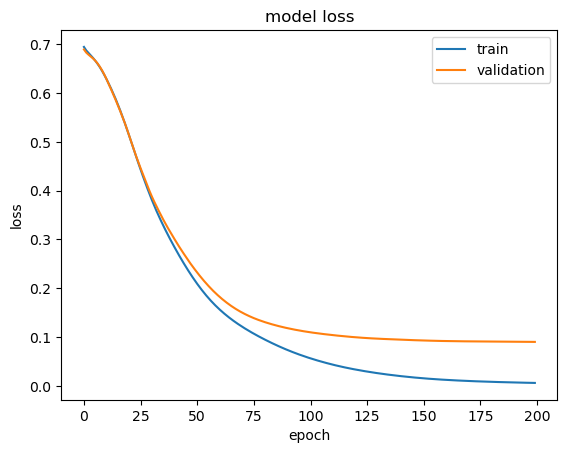

In [14]:
plt.figure()
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='validation')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

Similarly, we can plot the accuracy of our neural network on the binary classification task. The metric used in this example is the _binary accuracy_, which calculates the proportion of predictions that match labels or response variables. Other metrics may be used in different tasks -- for example, the _mean squared error_ is typically used to measure the accuracy for continuous response variables (e.g. polygenic risk scores, total serum cholesterol level, height, weight and systolic blood pressure).

Binary Accuracy = (Number of Correctly Predicted Examples) / (Total Number of Examples)

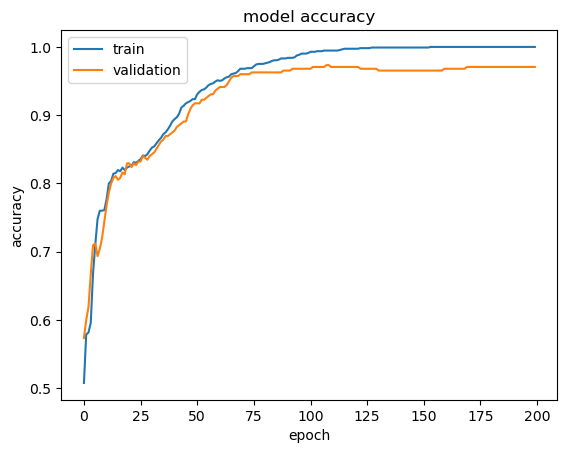

In [15]:
plt.figure()
plt.plot(train_accs, label='train')
plt.plot(val_accs,   label='validation')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

## Evaluate the model

- Evaluate the model on a fresh test set consisting of data that it has not observed at all during training.
- We plot the results as a confusion matrix

Confusion matrix:
 [[251   8]
 [  4 237]]
Normalised:
 [[0.96911197 0.03088803]
 [0.01659751 0.98340249]]


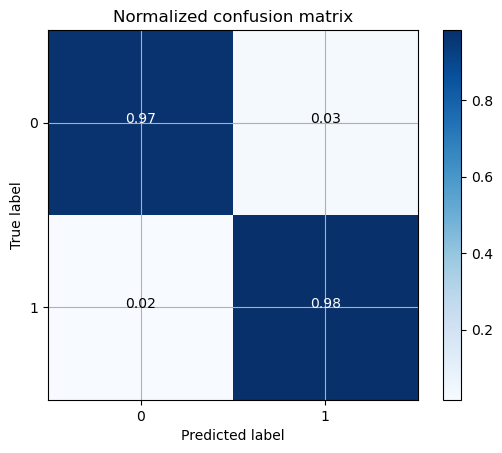

In [16]:
from sklearn.metrics import confusion_matrix
import itertools

# Predict on the test set
model.eval()
with torch.no_grad():
    predicted_labels = model(X_test).argmax(dim=1).numpy()

true_labels = y_test.numpy()

# Build confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
print('Confusion matrix:\n', cm)

# Normalise by true class totals
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print('Normalised:\n', cm_norm)

plt.imshow(cm_norm, cmap=plt.cm.Blues)
plt.title('Normalized confusion matrix')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0, 1]); plt.yticks([0, 1])
plt.grid('off')
for i, j in itertools.product(range(cm_norm.shape[0]), range(cm_norm.shape[1])):
    plt.text(j, i, format(cm_norm[i, j], '.2f'),
             horizontalalignment='center',
             color='white' if cm_norm[i, j] > 0.5 else 'black')

### True positive rate (sensitivity, recall)
TNR: specificity, selectivity or true negative rate TN / (TN + FP)
What percentages of sequences not binding could be identified as such.
0.97

FPR: fall-out or false positive rate  FP / (FP + TN)
What percentages of sequences not binding could NOT be identified as such.
0.03

FNR: miss rate or false negative rate FN / (FN + TP)
What percentages of all binding motifs could NOT be identified as such
0.01

TPR: sensitivity, recall, hit rate, or true positive rate TP / (FN + TP)
What percentages of all binding motifs could be identified as such.
0.99


## Saliency map: which bases drove the prediction?

A saliency map asks: *if I nudge each input base slightly, how much does the predicted binding probability change?*

In PyTorch this is straightforward — we enable gradients on the input tensor, do a forward pass, and call `.backward()` to get $\partial p / \partial x$ for every position. Positions with large gradients contributed most to the prediction.

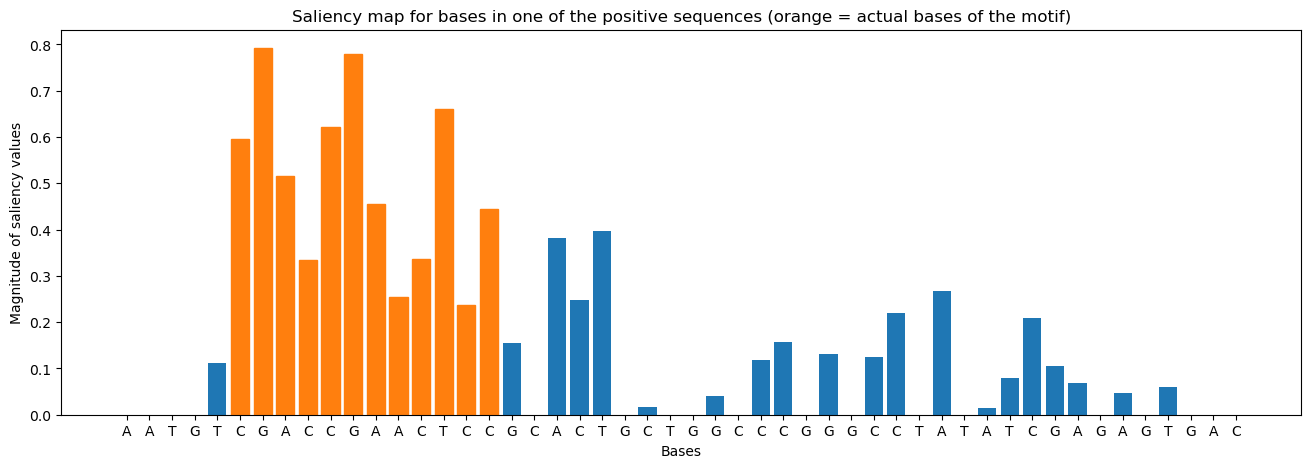

In [17]:
def compute_salient_bases(model, x):
    """
    x: numpy array of shape (seq_len, 4) — one one-hot-encoded sequence.
    Returns saliency scores of shape (seq_len,).
    """
    # Conv1d needs (1, 4, seq_len): add batch dim and permute
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).permute(0, 2, 1)
    x_tensor.requires_grad_(True)

    model.eval()
    logits = model(x_tensor)
    prob   = logits[0, 1]  # predicted score for class 1 (binding)
    prob.backward()

    # Gradients: (1, 4, seq_len) → permute back to (seq_len, 4) to match x
    gradients = x_tensor.grad.squeeze(0).permute(1, 0).detach().numpy()
    sal = (gradients * x).sum(axis=1)  # element-wise product, summed over channels
    sal = np.clip(sal, 0, None)
    return sal


sequence_index = 1999  # change this to inspect a different sequence
sal = compute_salient_bases(model, input_features[sequence_index])

plt.figure(figsize=[16, 5])
barlist = plt.bar(np.arange(len(sal)), sal)
[barlist[i].set_color('C1') for i in range(5, 17)]  # highlight the known motif positions
plt.xlabel('Bases')
plt.ylabel('Magnitude of saliency values')
plt.xticks(np.arange(len(sal)), list(sequences[sequence_index]))
plt.title('Saliency map for bases in one of the positive sequences'
          ' (orange = actual bases of the motif)')
plt.show()

## Does architecture matter? Comparing all three models

We now train all four architectures on the same data and compare their performance. The central question is whether the **inductive bias** of each model matches the structure of the problem.

**The problem structure**: each positive sequence contains the 12-base motif *CGACCGAACTCC* at a *random position*. Detecting it reliably requires **positional invariance** — the model should fire on the motif regardless of where it appears.

| Model | How it processes the sequence | Positional invariance? |
|-------|-------------------------------|------------------------|
| Linear | Weights each position independently (logistic regression) | No |
| MLP | Learns nonlinear combinations across all positions | No |
| CNN | Slides the same filter across every position (weight sharing) | Yes |

A CNN is specifically designed for this kind of problem. The comparison below lets you see whether this architectural advantage shows up in practice.

In [18]:
architectures = {
    'Linear': MotifLinear,
    'MLP':    MotifMLP,
    'CNN':    MotifCNN,
}

comparison_results = {}

for name, ModelClass in architectures.items():
    arch_model = ModelClass()
    optimizer  = torch.optim.Adam(arch_model.parameters())
    criterion  = nn.CrossEntropyLoss()

    val_curve = []

    for epoch in range(200):
        arch_model.train()
        logits = arch_model(X_train_sub)
        loss   = criterion(logits, y_train_sub)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        arch_model.eval()
        with torch.no_grad():
            val_logits = arch_model(X_val)
        val_curve.append((val_logits.argmax(1) == y_val).float().mean().item())

    arch_model.eval()
    with torch.no_grad():
        test_acc = (arch_model(X_test).argmax(1) == y_test).float().mean().item()

    comparison_results[name] = {'val_curve': val_curve, 'test_acc': test_acc}
    print(f'{name:8s}  test accuracy: {test_acc:.3f}')

Linear    test accuracy: 0.682
MLP       test accuracy: 0.740
CNN       test accuracy: 0.978


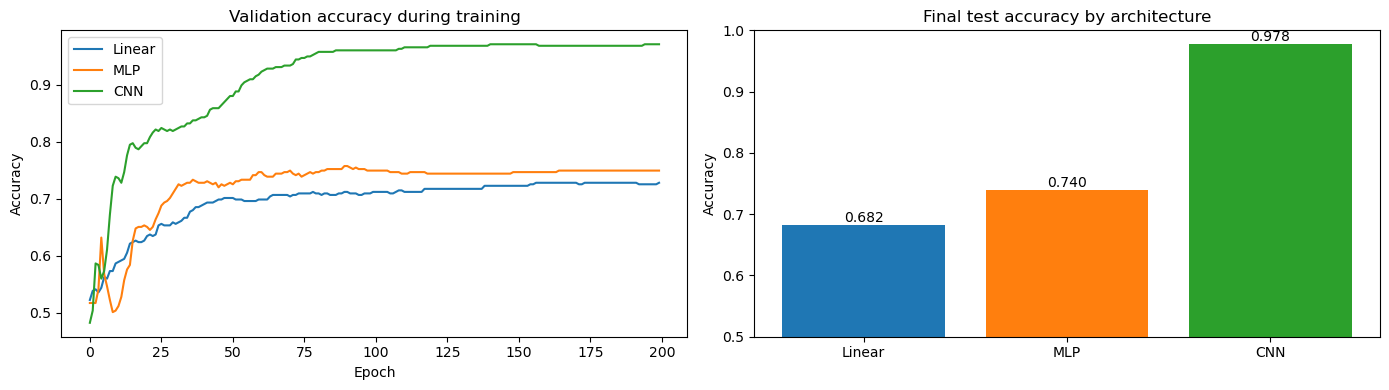

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, res in comparison_results.items():
    axes[0].plot(res['val_curve'], label=name)
axes[0].set_title('Validation accuracy during training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

names     = list(comparison_results.keys())
test_accs = [comparison_results[n]['test_acc'] for n in names]
axes[1].bar(names, test_accs, color=['C0', 'C1', 'C2', 'C3'])
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('Final test accuracy by architecture')
axes[1].set_ylabel('Accuracy')
for i, acc in enumerate(test_accs):
    axes[1].text(i, acc + 0.005, f'{acc:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()